<a href="https://colab.research.google.com/github/Caio-Oliveira98/Redes-neurais/blob/main/C%C3%B3pia_de_RN_Aula_6_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introdução ao Problema


O objetivo é prever o consumo de energia elétrica no Brasil com base em variáveis históricas,como mês, ano, categoria de consumo e outras.



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split #Estamos divindo para treinar e testar o modelo
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder #Duas funções pra pre processamento
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #métricas para fazer a avaliação do modelo , (mean square error mostra o quão distante estamos do resultado, já o r2score mostra a variabilidade.
from sklearn.compose import ColumnTransformer #utilizado para transformação de colunas
from sklearn.pipeline import Pipeline #salvar arquitetura da rede
from sklearn.neural_network import MLPRegressor #algoritmo multi layer perceptron
import matplotlib.pyplot as plt #importa o matplot para fazer alguns gráficos


# 2. Carregamento dos Dados


In [ ]:
# Carregue os dados (você precisará de autenticação na Base dos Dados)
df = pd.read_csv("/content/consumo_eletrico_brasil.csv")  # Carregando o banco de dados


In [ ]:
df.head() #Olhando as 5 primeiras linhas do banco de dados ( importante para verificar se o banco de dados importou corretamente os dados.)

,ano,mes,sigla_uf,tipo_consumo,numero_consumidores,consumo
0,2004,1,TO,Total,NaN,65876
1,2004,1,BA,Total,NaN,1444451
2,2004,1,PR,Total,NaN,1596274
3,2004,1,RS,Total,NaN,1780912
4,2004,1,GO,Total,NaN,630624


In [ ]:
df.shape #vendo o número de linhas e o número de colunas do banco de dados

(38880, 6)

In [ ]:
df.dtypes #vendo os tipos de informações

,0
ano,int64
mes,int64
sigla_uf,object
tipo_consumo,object
numero_consumidores,float64
consumo,int64


In [ ]:
df.value_counts("tipo_consumo") #Vendo os tipos de consumo e mostra a quantidade de informação para cada grupo dentro de "tipo_consumo".

,count
tipo_consumo,
Cativo,6480
Comercial,6480
Industrial,6480
Outros,6480
Residencial,6480
Total,6480


In [ ]:
df = df[df['tipo_consumo'] == 'Residencial'] #Utilizando um filtro para selecionar apenas os tipos de consumos residenciais.


In [ ]:
df.head() #Pedindo novamente o cabeçalho para ver se os dados estão corretos

,ano,mes,sigla_uf,tipo_consumo,numero_consumidores,consumo
1620,2004,1,RJ,Residencial,4900324.0,873761
1621,2004,1,MG,Residencial,5050859.0,628873
1622,2004,1,SP,Residencial,11535305.0,2074540
1623,2004,1,CE,Residencial,1724128.0,165168
1624,2004,1,ES,Residencial,811450.0,117209


In [ ]:
# Verificação de valores ausentes
print("\nValores ausentes por coluna:")
print(df.isnull().sum()) #Percorrendo linha por linha do data frame e transformar os dados "nulo" pra 1, como todas as colunas deram 0, nenhuma linha tinha o resultado nulo.


Valores ausentes por coluna:
ano                    0
mes                    0
sigla_uf               0
tipo_consumo           0
numero_consumidores    0
consumo                0
dtype: int64


# 3. Análise Exploratória dos Dados


In [ ]:
# Visualização estatística dos dados
print("\nResumo estatístico:")
df.describe() #Fazendo um resumo da tabela, mostrando informações como mês, ano, numero de consumidores e consumo


Resumo estatístico:


,ano,mes,numero_consumidores,consumo
count,6480.000000,6480.000000,6.480000e+03,6.480000e+03
mean,2013.500000,6.500000,2.343447e+06,3.736610e+05
std,5.766726,3.452319,3.122225e+06,5.885444e+05
min,2004.000000,1.000000,6.602100e+04,1.264500e+04
25%,2008.750000,3.750000,6.634945e+05,9.144250e+04
50%,2013.500000,6.500000,1.156076e+06,1.809670e+05
75%,2018.250000,9.250000,2.770015e+06,4.171208e+05
max,2023.000000,12.000000,1.920126e+07,4.324911e+06


In [ ]:
#Renomeando as colunas 'ano' e 'mes' para 'year' e 'month' e adicionando uma coluna 'day'
df = df.rename(columns={'ano': 'year', 'mes': 'month'})
df['day'] = 1  # Adiciona a coluna 'day' com o valor 1 para cada linha

# Convertendo para formato de data usando as colunas 'year', 'month', e 'day'
df['data'] = pd.to_datetime(df[['year', 'month', 'day']])

# Ordenando os dados por data
df = df.sort_values(by='data')

In [ ]:

# Agrupando os dados por data (somando o consumo e o número de consumidores de todos os estados)
df_brasil = df.groupby('data').agg({ #utilizando a função agg para simplificar o código
    'consumo': 'sum', #soma de todos os consumos
    'numero_consumidores': 'sum' #soma do numero de consumidores
}).reset_index()


In [ ]:
df_brasil.head() #chamando a base de dados brasil para poder analisar o banco de dados do Brasil

,data,consumo,numero_consumidores
0,2004-01-01,6780672,45430039.0
1,2004-02-01,6429231,45630098.0
2,2004-03-01,6600331,45874004.0
3,2004-04-01,6808996,46044907.0
4,2004-05-01,6477331,45965740.0


In [ ]:

# Criando as colunas de consumo dos últimos 12 meses
for i in range(1, 13):
    df_brasil[f'consumo_mes_{i}'] = df_brasil['consumo'].shift(i) #criando a informação consumo, quando for 1 ele me tratá a linha anterior
    #caso seja 2 irá ser 2 linhas anteriores


In [ ]:
df_brasil.head() #chamando a base de dados para visualizar.

,data,consumo,numero_consumidores,consumo_mes_1,consumo_mes_2,consumo_mes_3,consumo_mes_4,consumo_mes_5,consumo_mes_6,consumo_mes_7,consumo_mes_8,consumo_mes_9,consumo_mes_10,consumo_mes_11,consumo_mes_12
0,2004-01-01,6780672,45430039.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-02-01,6429231,45630098.0,6780672.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2004-03-01,6600331,45874004.0,6429231.0,6780672.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004-04-01,6808996,46044907.0,6600331.0,6429231.0,6780672.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2004-05-01,6477331,45965740.0,6808996.0,6600331.0,6429231.0,6780672.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# Removendo linhas com valores nulos (necessário para as primeiras linhas que não têm 12 meses anteriores)
df_brasil.dropna(inplace=True) #utilizando o inplace = true para salvar a base de dados já que os valores na foram dropados)

# Exibindo o dataframe processado
(df_brasil.head())

,data,consumo,numero_consumidores,consumo_mes_1,consumo_mes_2,consumo_mes_3,consumo_mes_4,consumo_mes_5,consumo_mes_6,consumo_mes_7,consumo_mes_8,consumo_mes_9,consumo_mes_10,consumo_mes_11,consumo_mes_12
12,2005-01-01,7118524,47310841.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0,6600331.0,6429231.0,6780672.0
13,2005-02-01,6758323,47370980.0,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0,6600331.0,6429231.0
14,2005-03-01,6865206,47537195.0,6758323.0,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0,6600331.0
15,2005-04-01,7131728,47628550.0,6865206.0,6758323.0,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0
16,2005-05-01,6718136,47646178.0,7131728.0,6865206.0,6758323.0,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0


In [ ]:
dates = df_brasil['data']  # Salvando as datas para usar no gráfico


In [ ]:
# Selecionando variáveis de entrada (últimos 12 meses de consumo e consumidores) e variável alvo (consumo atual)
X = df_brasil[[f'consumo_mes_{i}' for i in range(1, 13)] + ["numero_consumidores"]] #o X será todos os meses de consumo + o numero de consumidores
y = df_brasil['consumo'] #o Y será a coluna consumo.


In [ ]:
X

,consumo_mes_1,consumo_mes_2,consumo_mes_3,consumo_mes_4,consumo_mes_5,consumo_mes_6,consumo_mes_7,consumo_mes_8,consumo_mes_9,consumo_mes_10,consumo_mes_11,consumo_mes_12,numero_consumidores
12,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0,6600331.0,6429231.0,6780672.0,47310841.0
13,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0,6600331.0,6429231.0,47370980.0
14,6758323.0,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0,6600331.0,47537195.0
15,6865206.0,6758323.0,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,6808996.0,47628550.0
16,7131728.0,6865206.0,6758323.0,7118524.0,6643360.0,6631181.0,6606503.0,6604380.0,6304466.0,6292461.0,6291082.0,6477331.0,47646178.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,12523259.0,12778367.0,13065273.0,13658027.0,14313505.0,13680903.0,13310736.0,13688579.0,12949693.0,12605204.0,12505341.0,12075634.0,80413661.0
236,12954936.0,12523259.0,12778367.0,13065273.0,13658027.0,14313505.0,13680903.0,13310736.0,13688579.0,12949693.0,12605204.0,12505341.0,80393905.0
237,13618011.0,12954936.0,12523259.0,12778367.0,13065273.0,13658027.0,14313505.0,13680903.0,13310736.0,13688579.0,12949693.0,12605204.0,80681928.0
238,14337287.0,13618011.0,12954936.0,12523259.0,12778367.0,13065273.0,13658027.0,14313505.0,13680903.0,13310736.0,13688579.0,12949693.0,80779920.0


In [ ]:
# Normalizando os dados
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


Validação


In [ ]:

# Definindo o corte temporal para 80% dos dados para treino e 20% para teste
train_size = int(len(X) * 0.8) #tamanho da linha do x * 0,8 = 80% da base de dados para utilizar como treinamento
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [ ]:
dates_test = dates.iloc[train_size:]  # salvando as datas correspondentes ao conjunto de teste, para saber quando o meu treino foi iniciado.


In [ ]:

# Construindo o modelo MLP
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter = 500,  activation='identity', random_state = 152)


In [ ]:
mlp_model1 = MLPRegressor(hidden_layer_sizes=(124, 64), max_iter = 600,  activation='identity', random_state = 152)
mlp_model2 = MLPRegressor(hidden_layer_sizes=(124, 64), max_iter = 600,  activation='relu', random_state = 152)


In [ ]:
# Treinando o modelo
#ajustando os dados de treino
mlp_model.fit(X_train, y_train)
mlp_model1.fit(X_train, y_train)
mlp_model2.fit(X_train, y_train)



/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(124, 64), max_iter=600, random_state=152)

In [ ]:

# Fazendo previsões no conjunto de teste
y_pred = mlp_model.predict(X_test)
y_pred1 = mlp_model1.predict(X_test)
y_pred2 = mlp_model2.predict(X_test)


In [ ]:

# Avaliação do modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


mse1 = mean_squared_error(y_test, y_pred1)
mae1 = mean_absolute_error(y_test, y_pred1)

mse2 = mean_squared_error(y_test, y_pred2)
mae2 = mean_absolute_error(y_test, y_pred2)


print("Mean Squared Error:", mse, mse1,mse2)
print("Mean Absolute Error:", mae, mae1, mae2)

Mean Squared Error: 165329152358725.2 162017032798656.78 164712523941310.47
Mean Absolute Error: 12830060.362391777 12700638.378841294 12806064.436907357


In [ ]:

# Exibindo algumas previsões para comparação
print("Previsões:", y_pred1[:5])
print("Valores Reais:", y_test[:5].values)

Previsões: [140875.30473489 141712.50608702 142548.25579187 142774.58821649
 142960.14946479]
Valores Reais: [11174696. 11462132. 11441479. 11957237. 11658879.]


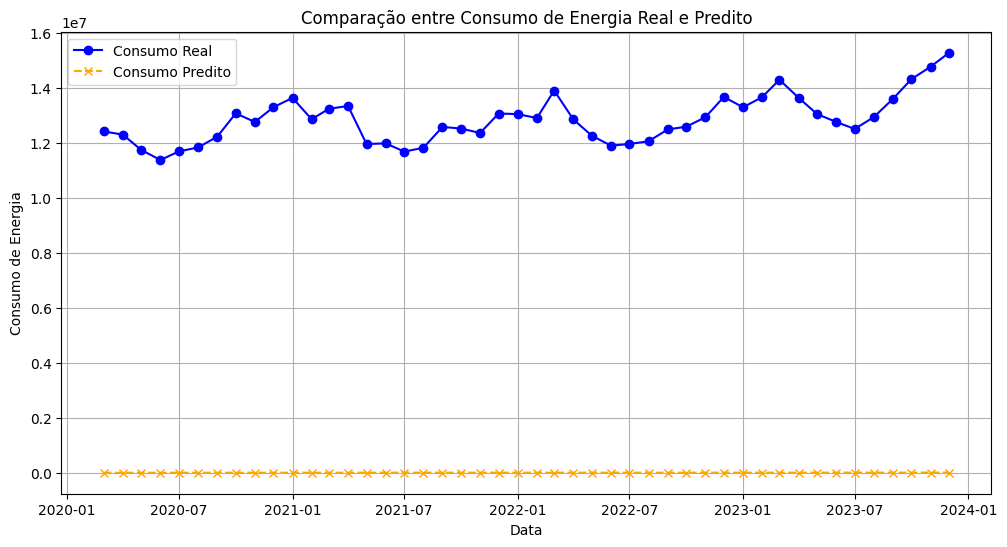

In [ ]:

# Gráfico de Consumo Real vs Predito
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, label="Consumo Real", color="blue", marker="o")
plt.plot(dates_test, y_pred, label="Consumo Predito", color="orange", linestyle="--", marker="x")
plt.xlabel("Data")
plt.ylabel("Consumo de Energia")
plt.title("Comparação entre Consumo de Energia Real e Predito")
plt.legend()
plt.grid(True)
plt.show()